Dataset Shape: (1117957, 22)

Dataset Preview:
   id  MonsoonIntensity  TopographyDrainage  RiverManagement  Deforestation  \
0   0                 5                   8                5              8   
1   1                 6                   7                4              4   
2   2                 6                   5                6              7   
3   3                 3                   4                6              5   
4   4                 5                   3                2              6   

   Urbanization  ClimateChange  DamsQuality  Siltation  AgriculturalPractices  \
0             6              4            4          3                      3   
1             8              8            3          5                      4   
2             3              7            1          5                      4   
3             4              8            4          7                      6   
4             4              4            3          3                   

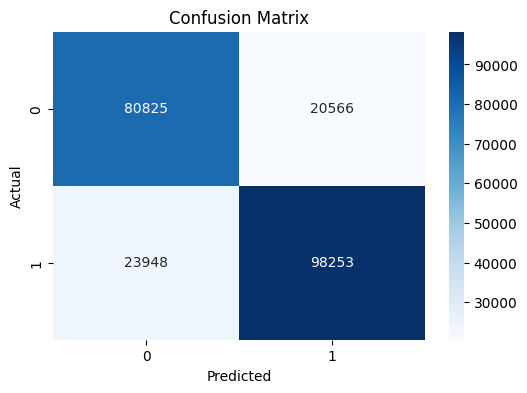

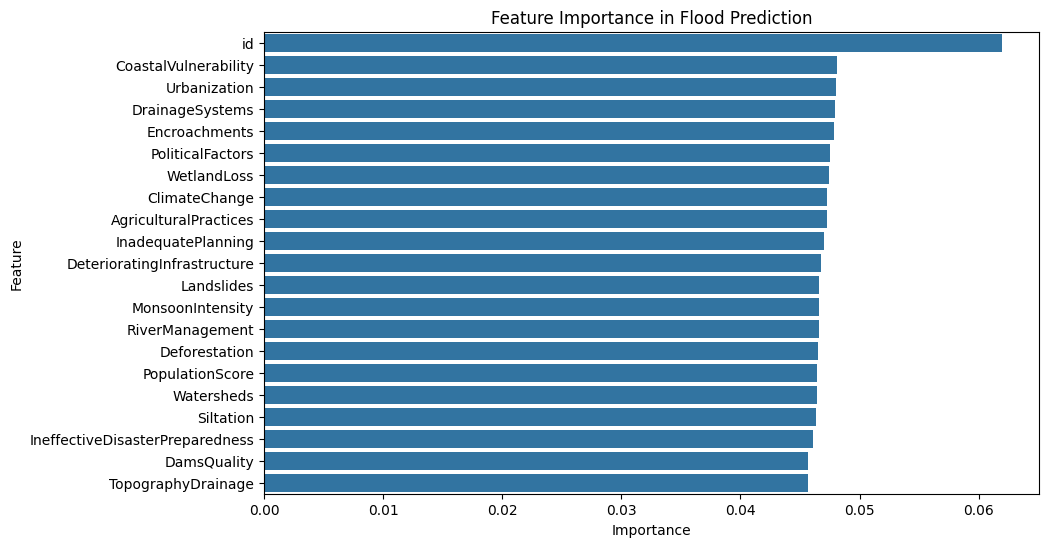


✅ Situation Normal — No Flood Risk


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [ ]:
!pip install pandas scikit-learn matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

data = pd.read_csv("/train.csv")

print("Dataset Shape:", data.shape)
print("\nDataset Preview:")
print(data.head())

y = (data["FloodProbability"] >= 0.5).astype(int)
X = data.drop("FloodProbability", axis=1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("\nTraining samples:", X_train.shape)
print("Testing samples:", X_test.shape)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print("\nModel Training Completed")

predictions = model.predict(X_test)

accuracy = accuracy_score(y_test, predictions)

print("\nModel Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_test, predictions))

cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

importance = model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x="Importance", y="Feature", data=feature_importance)
plt.title("Feature Importance in Flood Prediction")
plt.show()

def early_warning_system(input_data):

    prediction = model.predict([input_data])

    if prediction[0] == 1:
        print("\n⚠️ EARLY WARNING: HIGH FLOOD RISK DETECTED")

        resources = {
            "Rescue Boats": 6,
            "Medical Teams": 4,
            "Food Supply Trucks": 5,
            "Evacuation Buses": 3
        }

        print("\n🚑 Allocating Emergency Resources:")

        for resource, number in resources.items():
            print(resource, ":", number)

    else:
        print("\n✅ Situation Normal — No Flood Risk")

sample_input = X.iloc[0].values

early_warning_system(sample_input)